# Exercise 3
### Computer Vision, Fall 2026
#### Name: <font color='blue'>*write your name here*</font>
---
**Instructions:**
- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Wednesday 23.9 at 16.00</font> via Moodle.


## Ex 3.1. Hough Transform (4 p)
Detect edges in the image 'Corridor1.jpg' using OpenCV's Canny edge detector (cv2.Canny).
After finding possible edges, implement yourself a Hough line detector based on the
method presented at the lectures. Use the Hough line detector to detect lines in the given image and visualize your computed lines using Matplotlib.

Your implementation of the Hough line detector should be based on Numpy arrays and not use the OpenCV function for Houghlines. For validation purpose only, you may use OpenCV's built-in functions for computing Hough lines (cv2.HoughLines) to compare its results to yours. 


In [1]:
#imports
import cv2
import numpy as np
from matplotlib import pyplot as plt

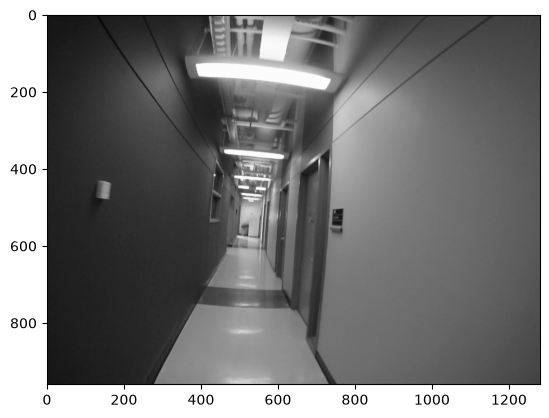

In [4]:
#reading and plotting image
image = cv2.imread("./images/Corridor1.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(image, cmap='gray')
plt.show()

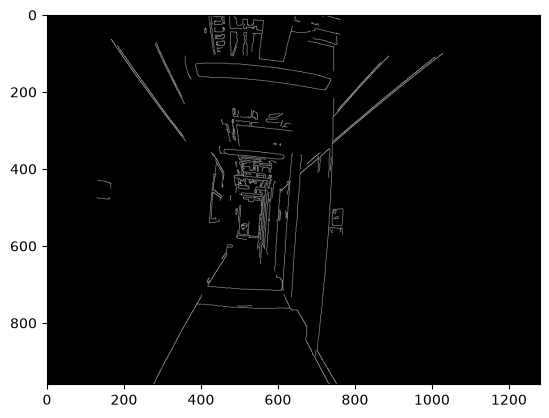

(array([  0,   0,   0, ..., 959, 959, 959], shape=(15126,)),
 array([421, 425, 432, ..., 278, 733, 752], shape=(15126,)))

In [48]:
#canny
canny_og = cv2.Canny(image, threshold1=75, threshold2=200)
plt.imshow(canny_og, cmap='gray')
plt.show()

In [44]:
#hough line detection
angles = np.arange(-90, 90, 1)
thetas = np.radians(angles)
height, width = np.shape(image)
rho_max = int(np.sqrt((height**2+width**2)))
#accumulates votes for lines
accumulator = np.zeros((2*rho_max, len(thetas)), dtype=np.int32)

type(accumulator[0][0]), \
angles[:3], theta[:3], \
x, y, \
rhos[:3], rho_max, \
np.shape(rhos), np.shape(thetas)


(numpy.int32,
 array([-90, -89, -88]),
 array([-1.57079633, -1.55334303, -1.53588974]),
 960,
 1280,
 array([-1280.        , -1263.05073962, -1245.71674175]),
 1600,
 (180,),
 (180,))

In [88]:
#AI upgraded
edges_row, edges_col = np.where(canny_og == 255)

for i, theta in enumerate(thetas):
    # x is column (horizontal), y is row (vertical)
    rhos = edges_col * np.cos(theta) + edges_row * np.sin(theta)
    rho_indices = np.round(rhos + rho_max).astype(int)
    np.add.at(accumulator, (rho_indices, i), 1)

# for i, theta in enumerate(thetas):
#     # x is column (horizontal), y is row (vertical)
#     for x, y in zip(edges_col, edges_row):
#         rho = x * np.cos(theta) + y * np.sin(theta)
#         rho_idx = int(round(rho + rho_max))
#         accumulator[rho_idx, i] += 1



In [83]:
#old and a bit wrong
# edges_row, edges_col = np.where(canny_og == 255)

# for i in range(0, len(thetas)):
#     for x, y in zip(edges_row, edges_col):
#         rho = x*np.cos(theta) + y*np.sin(theta)
#         rho_idx = int(rho+rho_max)
#         accumulator[rho_idx, i] += 1
# np.nonzero(accumulator)

# edges[0][:50], edges[1]

(array([1738, 1738, 1738, ..., 2629, 2629, 2629], shape=(160560,)),
 array([  0,   1,   2, ..., 177, 178, 179], shape=(160560,)))

In [ ]:
#visualization
width = image.shape[1]
xs = np.array(range(int(width/4)))
plt.figure(figsize=(20,30))
plt.imshow(image)

for j in range(len(P[0])):    
    #ys = ...
    
    lines_fp = np.array([xs,ys])
    
    #Rotating the lines, so that their origin is image origin (top left)
    lin = lines_fp.copy()
    factor = np.array([[0,1],[-1,0]])
    lines_fp= np.dot(factor , lines_fp)
    
    plt.plot(lines_fp[0],np.abs(lines_fp[1]))

## Ex 3.2 Hough Circle Transform (4 p)

Detect edges in the image 'Coins.jpg' using OpenCV's Canny edge detector (cv2.Canny). After finding possible edges, implement yourself a Hough circle detector based on the Hough transform method presented at the lectures.

Assume that the radii of the circles are within the range of 20 to 50 pixels. For each edge point (x,y), vote for possible circle centers (a,b) and radii r using the circle parametrization

$a = x−rcosθ,$
$b = y−rsinθ$

where θ represents the angle around the circle.

Construct a Hough accumulator for the parameters $(a,b,r)$, and use the accumulator to detect the circles in the image. Visualize your detected circles on the original image using Matplotlib.

Your implementation of the Hough circle detector should be based on NumPy arrays and not use OpenCV's function for Hough circles. For validation purpose only, you may use OpenCV's built-in function for computing Hough circles (cv2.HoughCircles) to compare its results to yours.


In [ ]:
# imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

## Ex 3.3 Direct Linear Transformation (4 p)

Implement the normalized DLT (Direct Linear Transformation) algorithm
1) Take two images e.g. with your smartphone while rotating the phone a few degrees in between.

2) Detect features from those images using OpenCv's SIFT detector and OpenCV's BFFMatcher (https://docs.opencv.org/3.4/da/df5/tutorial_py_sift_intro.html and https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html)

3) Compute the 3x3 homography matrix H procedure such that xi’=Hxi (in homogenous coordinates) using DLT and at least 4-point correspondences.

To get improved performance normalize the points using the following algorithm:
- Normalize points xi: First move their average to (0,0) by substracting their mean. Then scale them to average length of 2 . The final transformation is: T= Tscale*Ttranslate 

- Do the same to points xi’, and obtain the transformation T’ For each correspondence xi ↔xi’ compute the matrix Ai (using the transformed points); see explanation and definitions from lecture slides. Assemble the n 2x9 matrices Ai into a single 2nx9 matrix A. Obtain the SVD of A. Here you can use Numpys SVD function. The unit singular vector corresponding to the smallest singular value is the solution h. Specifically, if A=UDVT with D diagonal with positive diagonal entries, arranged in descending order down the diagonal, then h is the last column of V. Denormalize the solution: inv(T’)*H*T.

(“Multiple View Geometry in computer vision”, by R. Hartley and A. Zisserman, p. 92)

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
#read in images
img1_path = "" 
img2_path = ""
I1 = cv2.imread(img1_path)
I1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
I2 = cv2.imread(img2_path)
I2 = cv2.cvtColor(I2, cv2.COLOR_BGR2GRAY)

In [ ]:
#feature extraction
#...

In [ ]:
#feature matching
#...

In [ ]:
#generating 2 sets of homogeneous points
#...

In [ ]:
#Takes in 2d points in homogeneous coordinates and returns normalized coordinates and the normalization matrix
def normalize(points):
    #...
    return norm_pts, T

In [ ]:
#apply normalizing function
#normalize(points1)
#normalize(points2)

In [ ]:
#build A matrix according to the slides
#A = ...

In [ ]:
#compute svd
u,s,v =np.linalg.svd(A)
H = v[-1].reshape(3,3)

In [ ]:
#denormalize solution
# H = ...

In [ ]:
#use cv2.warpPerspective to visualize the homography matrix H
im_dst = cv2.warpPerspective(I1, np.linalg.inv(H), (I1.shape[1],I1.shape[0]))
plt.imshow(im_dst)